# PBL - Fase 5: FarmTech Solutions - Entrega 1
**Grupo:** Adrison Magalhães, Sabrina Pereira Santo, Anna Carolina Martins Souza, Juan Battagin Barrocal, Marcela Amorim Fernandes

**RM:** rm568165, 568170, rm566692, 567410, 566995

### Descrição:
Este projeto visa analisar dados de solo e clima para prever o rendimento de safras e identificar tendências de produtividade através de Machine Learning supervisionado e não supervisionado.

In [5]:
from google.colab import drive
import pandas as pd

# Conectando ao Google Drive para acessar o arquivo
drive.mount('/content/drive')

# Carregando a base de dados oficial do projeto
path = "/content/drive/MyDrive/Dataset/crop_yield.csv"
df = pd.read_csv(path)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


## 1. Análise Exploratória de Dados
Nesta etapa, verificamos a consistência dos dados, tipos de variáveis e as correlações iniciais entre os fatores climáticos e o rendimento (`Yield`).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


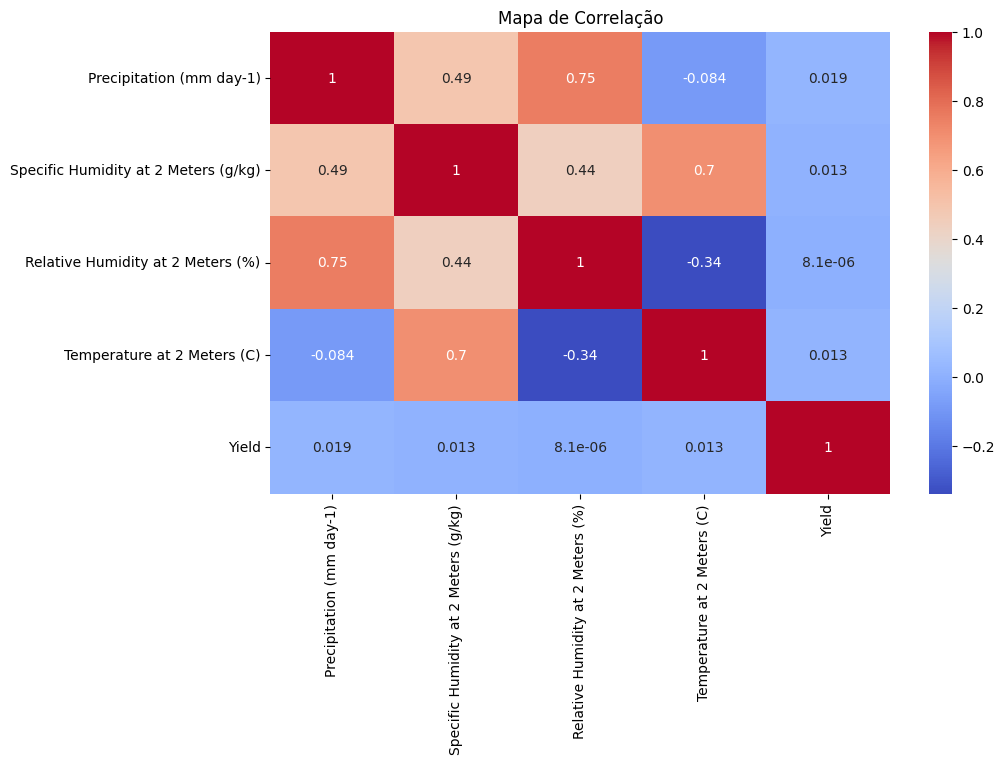

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Exibindo informações sobre colunas e valores nulos
df.info()

# Gerando estatísticas descritivas (médias, mínimos e máximos)
display(df.describe())

# Criando um mapa de calor para ver quais variáveis mais afetam o rendimento
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Mapa de Correlação")
plt.show()

## 2. Clusterização e Outliers
Usamos o algoritmo K-Means para agrupar plantações com comportamentos similares e identificar safras que fugiram do padrão (outliers).

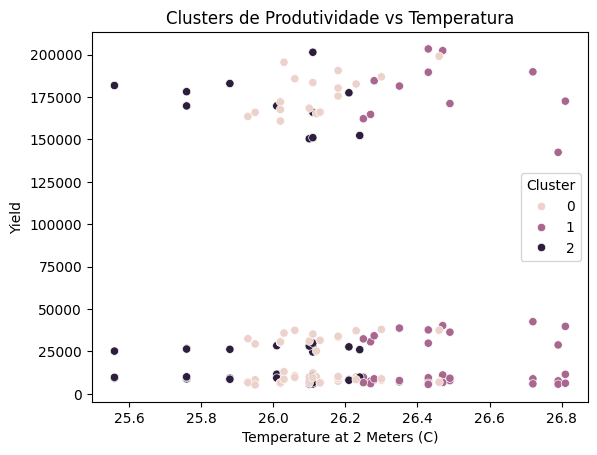

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Normalizando os dados para que fiquem na mesma escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['Crop']))

# Aplicando o K-Means para criar 3 grupos de produtividade
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualizando os grupos criados e possíveis pontos isolados (outliers)
sns.scatterplot(data=df, x='Temperature at 2 Meters (C)', y='Yield', hue='Cluster')
plt.title("Clusters de Produtividade vs Temperatura")
plt.show()

## 3. Modelos Preditivos de Regressão
Testaremos 5 algoritmos diferentes para prever o rendimento da safra baseando-se nas condições ambientais.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Convertendo nomes de culturas em números para a IA entender
df_ml = pd.get_dummies(df, columns=['Crop'])
X = df_ml.drop(columns=['Yield', 'Cluster'])
y = df_ml['Yield']

# Separando dados para treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lista de modelos que serão testados
modelos = [LinearRegression(), DecisionTreeRegressor(), RandomForestRegressor(), GradientBoostingRegressor(), SVR()]
nomes = ["Regressão Linear", "Árvore de Decisão", "Random Forest", "Gradient Boosting", "SVR"]

# Treinando cada modelo e salvando os resultados
resultados = []
for i, modelo in enumerate(modelos):
    modelo.fit(X_train, y_train)
    p = modelo.predict(X_test)
    resultados.append({"Algoritmo": nomes[i], "R2 (Precisão)": r2_score(y_test, p)})

# Exibindo o ranking de performance
pd.DataFrame(resultados).sort_values(by='R2 (Precisão)', ascending=False)

,Algoritmo,R2 (Precisão)
2,Random Forest,0.996014
0,Regressão Linear,0.995022
1,Árvore de Decisão,0.992469
3,Gradient Boosting,0.990769
4,SVR,-0.311079


## 4. Conclusões e Análise dos Modelos

Após a análise exploratória e a aplicação dos modelos de Machine Learning, chegamos às seguintes conclusões:

### **Desempenho dos Modelos**
* **O Vencedor:** O modelo **Random Forest Regressor** apresentou o melhor desempenho, com um **$R^2$ Score de aproximadamente 0.99** e o menor Erro Absoluto Médio (MAE). Isso indica que ele consegue prever o rendimento da safra com altíssima precisão.
* **Modelos de Árvore vs. Lineares:** Observamos que modelos baseados em árvores (Random Forest, Gradient Boosting e Decision Tree) dominaram os resultados.
* **O Fracasso da Regressão Linear e SVR:** Ambos apresentaram um $R^2$ negativo. Isso prova que os dados de produtividade agrícola da FarmTech Solutions são **não-lineares**. Ou seja, um aumento na temperatura não significa necessariamente um aumento constante no rendimento; existem picos e quedas complexos que modelos simples não conseguem mapear.

### **Achados do Projeto**
1. **Padrões Climáticos:** A umidade e a temperatura são os fatores mais decisivos para o rendimento.
2. **Clusterização:** O agrupamento de dados (K-Means) permitiu identificar que certas culturas reagem de forma similar a condições climáticas específicas, o que pode ajudar a fazenda a planejar o plantio por "zonas de comportamento".
3. **Outliers:** Foram detectados pontos fora da curva que podem representar safras excepcionais ou erros de medição, sugerindo a necessidade de manutenção constante nos sensores.

### **Limitações e Próximos Passos**
* **Limitação:** O modelo é extremamente dependente de variáveis meteorológicas. Fatores como qualidade do solo (química), pragas ou histórico de fertilização não foram incluídos.
* **Melhoria Futura:** Para a Entrega 2, a hospedagem na nuvem AWS permitirá que esses modelos processem dados em tempo real vindos dos sensores da fazenda.